# Performing gradient optimization of a pulse sequence

Here we walk through an example of optimizing a single qubit gate using `qiskit_dynamics`. This tutorial requires JAX - see the How-to guide on using JAX for more detail on how to configure `qiskit-dynamics` to work with JAX. 

We will optimize an $X$-gate on a model of a qubit system using the following steps:
1. Configure `qiskit-dynamics` to work with the JAX backend. 
2. Setup a `Solver` instance with the model of the system. 
3. Define an unconstrained parameterization for signals with piecewise-constant envelopes that are bounded and smooth. 
4. Define the target function measuring gate performance - in this case the gate fidelity.
5. Define the overall objective function, involving generating the signals from parameters, simulating, and computing the metric of gate performance.
6. Use JAX to differentiate the objective, and then optimize using the gradient descent BFGS method available via `scipy.optimize.minimize`. Observe the results.

## 1. Configure to use JAX

First, set JAX to operate in 64-bit mode, and set it as the default backend for `qiskit-dynamics`.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

from qiskit_dynamics import dispatch
dispatch.set_default_backend('jax')

## 2. Setup the solver

Here we will setup a `Solver` with a simple model of a qubit. The Hamiltonian is:

$$H(t) = 2 \pi \nu \frac{Z}{2} + 2 \pi r s(t) \frac{X}{2}$$

We will setup the problem to be in the rotating frame of the drift term.

Also note: The `Solver` is initialized *without* signals, as we will update these and optimize over this later.

In [2]:
import numpy as np
from qiskit.quantum_info import Operator
from qiskit_dynamics import Solver

v = 5.
r = 0.02

drift = 2 * np.pi * v * Operator.from_label('Z') / 2
drive_term = 2 * np.pi * r * Operator.from_label('X') / 2

ham_solver = Solver(hamiltonian_operators=[drive_term],
                    drift=drift,
                    rotating_frame=drift)

## 3. Define and parameterize the class of pulses to optimize over

Part of optimizing a pulse sequence is choosing a class of pulses to optimize over, and then choosing a particular parameterization of that class. As we wish to use an *unconstrained* gradient optimization method (BFGS), we need to make sure that our parameterization is:
- Unconstrained, in the sense that all parameters can take any real value, and
- The parameterization can be *differentiated* using JAX.

Here, we wish to optimize over a set of piecewise constant signals, with carrier frequency on resonance, and such that the piecewise constant envelope is:
- Bounded between $[-1, 1]$,
- Smooth, in the sense that the change between adjacent samples is small, and
- The pulse starts and ends at $0$.

We implement this parameterization as follows:
- The input is an array `x` of "unnormalized" samples for the piecewise-constant envelope.
- The array `x` is mapped, entry-wise, into the interval $[-1, 1]$, via a JAX-differentiable function.
- To achieve smoothness and that the pulse starts and ends at $0$, the samples are padded with $0$s a the beginning and end, and then passed through a convolution filter to smooth them out.

We remark that there are many other parameterizations that may achieve the same ends, and may have more efficient strategies for achieving a value of $0$ at the beginning and end of the pulse. This is only meant to demonstrate the need for such an approach, and one simple example of one.

In [3]:
from qiskit_dynamics.dispatch import Array
from qiskit_dynamics.signals import DiscreteSignal, Convolution

# differentiable function for mapping an array of arbitrary real values
# into the interval [-1, 1]
def normalize_samples(samples):
    return np.arctan(Array(samples)) / (np.pi / 2)

# define convolution filter. We will use a gaussian kernel
def gaus(t):
    sigma = 15
    _dt = 0.1
    return 2.*_dt/np.sqrt(2.*np.pi*sigma**2)*np.exp(-t**2/(2*sigma**2))

# construct a Convolution object
convolution = Convolution(gaus)

# define the full signal mapping from parameters to DiscreteSignal
def signal_mapping(params):
    samples = Array(params)
    
    # map samples into [-1, 1]
    bounded_samples = normalize_samples(samples)
    
    # pad with 0 at beginning
    padded_samples = np.append(Array([0], dtype=complex), bounded_samples)
    
    # apply filter
    output_signal = convolution(DiscreteSignal(dt=1., samples=padded_samples))
    
    # set carrier frequency to v
    output_signal.carrier_freq = v
    
    return output_signal

Observe, for example, the signal generated when all parameters are $1.$:

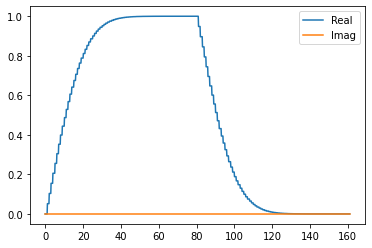

In [4]:
signal = signal_mapping(np.ones(80) * 1e8)
signal.draw(t0=0., tf=signal.duration * signal.dt, n=1000, function='envelope')

In [5]:
signal.duration

161

## 4. Define gate fidelity

We will optimize an $X$ gate, and define the fidelity of a unitary via the standard fidelity measure:

$$f(U) = \frac{|\text{Tr}(XU)|^2}{4}$$

In [6]:
X_op = Array(Operator.from_label('X'))

def fidelity(U):
    U = Array(U)
    
    return np.abs(np.sum(X_op * U))**2 / 4.

## 5. Define the objective function

The function we want to optimize consists of:
- Taking a list of input samples and applying the signal mapping.
- Simulating the Schrodinger equation over the length of the pulse sequence.
- Computing and return the infidelity (we minimize $1-f(U)$).

In [7]:
def objective(samples):
    
    # apply signal mapping
    signal = signal_mapping(samples)
    
    # simulate
    solver_copy = ham_solver.copy()
    solver_copy.signals = [signal]
    
    # set final time to the length of the signal 
    tf = signal.duration * signal.dt
    
    results = solver_copy.solve(y0=np.eye(2, dtype=complex), 
                                t_span=[0, tf],
                                method='jax_odeint', atol=1e-8, rtol=1e-8)
    U = results.y[-1]
    
    # compute fidelity
    fid = fidelity(U)
    
    # return infidelity
    return 1. - fid.data

## 6. Perform JAX transformations and optimize

Finally, we use `scipy.optimize.minimize` to optimize the objective. We transform the `objective` function into one that computes both the original objective, as well as as its gradient, using `jax.value_and_grad`, and then just-in-time compile it using `jax.jit`. This function is then passed to `minimize` with the flag `jac=True` to indicate that the function also computes the gradient, and select the gradient method BFGS.

In [8]:
from jax import jit, value_and_grad
from scipy.optimize import minimize

jit_grad_obj = jit(value_and_grad(objective))

initial_guess = np.random.rand(80) - 0.5

opt_results = minimize(fun=jit_grad_obj, x0=initial_guess, jac=True, method='BFGS')
print(opt_results.message)
print('Number of function evaluations: ' + str(opt_results.nfev))
print('Function value: ' + str(opt_results.fun))

Optimization terminated successfully.
Number of function evaluations: 11
Function value: -5.490720211831501e-08


The gate is optimized to an $X$ gate, with deviation within the numerical accuracy of the solver. We can draw the optimized signal, which is retrieved by applying the `signal_mapping` to the optimized parameters.

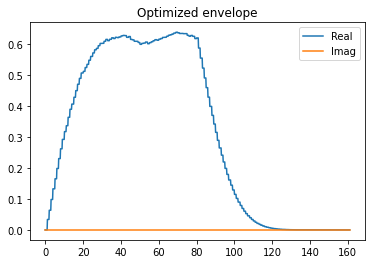

In [9]:
opt_signal = signal_mapping(opt_results.x)

opt_signal.draw(t0=0, tf=opt_signal.duration * opt_signal.dt, 
                n=1000, function='envelope', title='Optimized envelope')

Summing the signal samples yeilds approximately $\pm 50$, which is equivalent to what one would expect based on a rotating wave approximation analysis.

In [10]:
opt_signal.samples.sum()

Array(49.99765071)